<a href="https://colab.research.google.com/github/jenny005/geo-koopman/blob/main/GeoKoop_FourModel_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GeoKoop — All Three Benchmarks: Four-Model Comparison
**Before running:** `Runtime > Change runtime type > T4 GPU > Save`

Four models compared across Pendulum, FluidFlowBox, and Cylinder:

| # | Model | Dynamics | Role |
|---|-------|----------|------|
| 1 | **Classical Koopman / DMD** | fixed linear in observation space | analytic baseline |
| 2 | **Black-box NN** | `z_{t+1} = f_theta(z_t)`, unconstrained MLP | expressiveness upper bound |
| 3 | **Deep Koopman** | `z_{t+1} = K z_t`, learned encoder | structured linear baseline |
| 4 | **GeoKoop (proposed)** | `z_{t+1} = (K + N(z_t)) z_t` | geometry-aware |

$$z_{t+1} = \underbrace{K z_t}_{\text{linear}} + \underbrace{N(z_t)z_t}_{\text{curvature correction}}$$


In [ ]:
# ── Cell 1: Setup ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import scipy.io
import os, shutil

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU — Runtime > Change runtime type > T4 GPU')


Mounted at /content/drive
PyTorch 2.10.0+cu128
Device: cuda
GPU: Tesla T4


In [ ]:
BASE_DIR = "/content/drive/MyDrive/Koopman"

DATA_DIR = f"{BASE_DIR}/DeepKoopman_data/data"
CYLINDER = f"{BASE_DIR}/Cylinder_data/DATA/FLUIDS/CYLINDER_ALL.mat"


OUTPUT_DIR = f"{BASE_DIR}/outputs"
FIG_DIR    = f"{OUTPUT_DIR}/figures"
MODEL_DIR  = f"{OUTPUT_DIR}/models"
LOG_DIR    = f"{OUTPUT_DIR}/logs"

In [ ]:
# Cell 3: Shared model definitions — four models

# ── Autoencoder ────────────────────────────────────────────────
class AE(nn.Module):
    """Encoder-decoder with configurable hidden width."""
    def __init__(self, input_dim, latent_dim, hidden=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden//2),  nn.Tanh(),
            nn.Linear(hidden//2, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden//2), nn.Tanh(),
            nn.Linear(hidden//2, hidden),      nn.Tanh(),
            nn.Linear(hidden, input_dim),
        )
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)


# ── Model 2: Black-box NN ──────────────────────────────────────
class BlackBoxNN(nn.Module):
    """
    Unconstrained latent dynamics: z_{t+1} = f_theta(z_t).
    Same parameter budget as KoopmanCore (hidden=64) for a fair comparison.
    No K matrix, no spectral constraint, no geo regulariser.
    """
    def __init__(self, latent_dim, hidden=64):
        super().__init__()
        self.f = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),     nn.Tanh(),
            nn.Linear(hidden, latent_dim),
        )
    def forward(self, z): return self.f(z)


# ── Model 3 & 4: KoopmanCore ───────────────────────────────────
class KoopmanCore(nn.Module):
    """
    use_geo=False  ->  Deep Koopman:  z_{t+1} = K z_t
    use_geo=True   ->  GeoKoop:       z_{t+1} = (K + N(z_t)) z_t
    """
    def __init__(self, latent_dim, K_init=None, eps=1.0, use_geo=True):
        super().__init__()
        self.d = latent_dim; self.eps = eps; self.use_geo = use_geo
        K0 = torch.tensor(K_init[:latent_dim, :latent_dim],
                           dtype=torch.float32) if K_init is not None \
             else torch.eye(latent_dim)
        self.K = nn.Parameter(K0)
        if use_geo:
            self.N_net = nn.Sequential(
                nn.Linear(latent_dim, 64), nn.Tanh(),
                nn.Linear(64, 64),         nn.Tanh(),
                nn.Linear(64, latent_dim * latent_dim),
            )
            nn.init.zeros_(self.N_net[-1].weight)
            nn.init.zeros_(self.N_net[-1].bias)

    def forward(self, z):
        z_lin = z @ self.K.T
        if self.use_geo:
            B = z.shape[0]
            N = self.N_net(z).view(B, self.d, self.d)
            return z_lin + self.eps * torch.bmm(N, z.unsqueeze(-1)).squeeze(-1)
        return z_lin

    def geo_loss(self, z):
        if not self.use_geo: return torch.tensor(0., device=z.device)
        N = self.N_net(z).view(z.shape[0], self.d * self.d)
        return torch.mean(torch.norm(N, dim=1))


# ── Shared utilities ────────────────────────────────────────────
def spectral_penalty(K):
    ev = torch.linalg.eigvals(K.unsqueeze(0))
    return ((ev.abs() - 1.0) ** 2).mean()


def dmd_matrix(X, rank=20):
    """DMD operator from data matrix X (n_features, T)."""
    X1 = X[:, :-1]; X2 = X[:, 1:]
    U_, S_, Vt_ = np.linalg.svd(X1, full_matrices=False)
    rank = min(rank, int((S_ > 1e-10 * S_[0]).sum()))
    Ur = U_[:, :rank]; Vr = Vt_[:rank].T; Sr_inv = np.diag(1.0 / S_[:rank])
    return Ur @ (Ur.T @ X2 @ Vr @ Sr_inv) @ Ur.T


# ── Model 3/4 training loop ─────────────────────────────────────
def train_model(ae, koopman, x_t, x_tp1, use_geo, label,
                epochs_p1=500, epochs_p2=3000,
                rollout_steps=20, lam_geo=0.01,
                lr_ae=1e-3, lr_K=5e-5, lr_N=5e-4):
    params = [{'params': ae.parameters(), 'lr': lr_ae},
              {'params': [koopman.K],     'lr': lr_K}]
    if use_geo:
        params.append({'params': koopman.N_net.parameters(), 'lr': lr_N})
    opt = torch.optim.Adam(params)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.5)

    for epoch in range(epochs_p1 + epochs_p2):
        ae.train(); koopman.train(); opt.zero_grad()
        z = ae.encode(x_t); z_nxt = ae.encode(x_tp1)
        loss_rec  = ((ae.decode(z) - x_t)**2).mean()
        loss_dyn  = ((koopman(z) - z_nxt)**2).mean()
        loss_spec = spectral_penalty(koopman.K)
        loss_roll = torch.tensor(0., device=device)
        if epoch >= epochs_p1 and rollout_steps > 0:
            n = x_t.shape[0] - rollout_steps
            zr = ae.encode(x_t[:n]).detach()
            for k in range(rollout_steps):
                zr = koopman(zr)
                zt = ae.encode(x_t[k+1:k+1+n]).detach()
                loss_roll += ((zr - zt)**2).mean()
            loss_roll = torch.clamp(loss_roll / rollout_steps, max=5.0)
        loss_geo = koopman.geo_loss(z)
        loss = (loss_rec + 0.1*loss_dyn + 0.01*loss_spec + lam_geo*loss_geo) \
               if epoch < epochs_p1 else \
               (loss_rec + 1.0*loss_dyn + 0.5*loss_roll + 0.01*loss_spec + lam_geo*loss_geo)
        loss.backward()
        nn.utils.clip_grad_norm_(list(ae.parameters()) + list(koopman.parameters()), 0.5)
        opt.step(); sch.step()
        if epoch % 200 == 0:
            print(f'[{label}] {epoch:4d} | rec={loss_rec.item():.5f} '
                  f'dyn={loss_dyn.item():.5f} roll={loss_roll.item():.5f} '
                  f'geo={loss_geo.item():.4f}')


# ── Model 2 (Black-box NN) training loop ────────────────────────
def train_blackbox(ae, bb, x_t, x_tp1, label,
                   epochs_p1=500, epochs_p2=3000,
                   rollout_steps=20,
                   lr_ae=1e-3, lr_f=1e-3):
    """
    Two-phase training mirroring KoopmanCore for a fair comparison.
    No spectral penalty (no K), no geo regulariser.
    """
    opt = torch.optim.Adam(
        list(ae.parameters()) + list(bb.parameters()),
        lr=lr_ae)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.5)

    for epoch in range(epochs_p1 + epochs_p2):
        ae.train(); bb.train(); opt.zero_grad()
        z = ae.encode(x_t); z_nxt = ae.encode(x_tp1)
        loss_rec = ((ae.decode(z) - x_t)**2).mean()
        loss_dyn = ((bb(z) - z_nxt)**2).mean()
        loss_roll = torch.tensor(0., device=device)
        if epoch >= epochs_p1 and rollout_steps > 0:
            n = x_t.shape[0] - rollout_steps
            zr = ae.encode(x_t[:n]).detach()
            for k in range(rollout_steps):
                zr = bb(zr)
                zt = ae.encode(x_t[k+1:k+1+n]).detach()
                loss_roll += ((zr - zt)**2).mean()
            loss_roll = torch.clamp(loss_roll / rollout_steps, max=5.0)
        loss = (loss_rec + 0.1*loss_dyn) if epoch < epochs_p1 else \
               (loss_rec + 1.0*loss_dyn + 0.5*loss_roll)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(ae.parameters()) + list(bb.parameters()), 0.5)
        opt.step(); sch.step()
        if epoch % 200 == 0:
            print(f'[{label}] {epoch:4d} | rec={loss_rec.item():.5f} '
                  f'dyn={loss_dyn.item():.5f} roll={loss_roll.item():.5f}')


# ── Rollout evaluation (same for all AE-based models) ───────────
@torch.no_grad()
def rollout_error(ae, dyn, X_data, steps=49):
    ae.eval(); dyn.eval()
    z = ae.encode(X_data[:, 0, :])
    errs = []
    for k in range(steps):
        z     = dyn(z)
        x_hat = ae.decode(z)
        err   = torch.norm(x_hat - X_data[:, k+1, :], dim=1).mean().item()
        errs.append(err)
    return np.array(errs)


# ── Plot colours and styles (consistent across all figures) ─────
COLORS = {
    'DMD':      '#888780',
    'BlackBox': '#F5A623',
    'Baseline': '#378ADD',
    'GeoKoop':  '#E24B4A',
}
STYLES = {
    'DMD':      ':',
    'BlackBox': '-.',
    'Baseline': '--',
    'GeoKoop':  '-',
}

print('Shared definitions ready.')
print('  Model 1: Classical Koopman / DMD   (analytic, no AE)')
print('  Model 2: BlackBoxNN                (train_blackbox)')
print('  Model 3: Deep Koopman (KoopmanCore use_geo=False)')
print('  Model 4: GeoKoop     (KoopmanCore use_geo=True)')


Shared definitions ready.
  Model 1: Classical Koopman / DMD   (analytic, no AE)
  Model 2: BlackBoxNN                (train_blackbox)
  Model 3: Deep Koopman (KoopmanCore use_geo=False)
  Model 4: GeoKoop     (KoopmanCore use_geo=True)


---
## Experiment 1 — Nonlinear Pendulum
Continuous spectrum: frequency shifts with energy → fixed linear K drifts → **15× improvement expected**

In [ ]:
# ── Cell 4: Pendulum — load data ───────────────────────────────────
SEQ_LEN = 51

def load_lusch(data_dir, name, split, seq_len):
    """Load Lusch-format CSV: (n_traj * seq_len, n_state) → (n_traj, seq_len, n_state)"""
    path = os.path.join(data_dir, f'{name}_{split}_x.csv')
    raw  = np.loadtxt(path, delimiter=',', dtype=np.float32)
    n_state = raw.shape[1]
    n_traj  = raw.shape[0] // seq_len
    return torch.tensor(
        raw[:n_traj*seq_len].reshape(n_traj, seq_len, n_state))

X_tr = load_lusch(DATA_DIR, 'Pendulum', 'train1', SEQ_LEN)
X_va = load_lusch(DATA_DIR, 'Pendulum', 'val',    SEQ_LEN)
X_te = load_lusch(DATA_DIR, 'Pendulum', 'test',   SEQ_LEN)
print(f'Pendulum — train: {X_tr.shape}  val: {X_va.shape}  test: {X_te.shape}')

# Normalise
mu  = X_tr.mean(dim=(0,1), keepdim=True)
sig = X_tr.std(dim=(0,1),  keepdim=True) + 1e-8
X_tr_n = ((X_tr - mu) / sig).to(device)
X_te_n = ((X_te - mu) / sig).to(device)

# Flatten to pairs
p_xt   = X_tr_n[:, :-1, :].reshape(-1, 2)
p_xtp1 = X_tr_n[:, 1:,  :].reshape(-1, 2)
print(f'Training pairs: {p_xt.shape}')
X_va_n = ((X_va - mu) / sig).to(device)


Pendulum — train: torch.Size([3500, 51, 2])  val: torch.Size([1000, 51, 2])  test: torch.Size([500, 51, 2])
Training pairs: torch.Size([175000, 2])


In [ ]:
# Pendulum — train all four models
P_LATENT = 4

# Pendulum uses its own subclass (N_net width=32, trajectory rollout)
class KoopmanPendulum(nn.Module):
    def __init__(self, d=4, use_geo=True):
        super().__init__()
        self.d = d; self.use_geo = use_geo
        self.K = nn.Parameter(torch.eye(d) + 0.01*torch.randn(d, d))
        if use_geo:
            self.N_net = nn.Sequential(
                nn.Linear(d, 32), nn.Tanh(),
                nn.Linear(32, 32), nn.Tanh(),
                nn.Linear(32, d*d))
            nn.init.zeros_(self.N_net[-1].weight)
            nn.init.zeros_(self.N_net[-1].bias)

    def forward(self, z):
        out = z @ self.K.T
        if self.use_geo:
            N = self.N_net(z).view(z.shape[0], self.d, self.d)
            out = out + torch.bmm(N, z.unsqueeze(-1)).squeeze(-1)
        return out

    def geo_loss(self, z):
        if not self.use_geo: return torch.tensor(0., device=z.device)
        return torch.mean(torch.norm(self.N_net(z).view(z.shape[0], self.d*self.d), dim=1))


def train_pendulum(ae, koop_or_bb, label, use_geo, is_bb=False,
                   epochs=3000, phase2=1000, rollout=20, lam_geo=0.01):
    if is_bb:
        # Black-box: plain Adam on ae + bb together
        opt = torch.optim.Adam(
            list(ae.parameters()) + list(koop_or_bb.parameters()), lr=1e-3)
    else:
        params = [{'params': ae.parameters(), 'lr': 1e-3},
                  {'params': [koop_or_bb.K],  'lr': 5e-5}]
        if use_geo:
            params.append({'params': koop_or_bb.N_net.parameters(), 'lr': 5e-4})
        opt = torch.optim.Adam(params)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.5)

    xt   = X_tr_p[:, :-1, :].reshape(-1, 2)
    xtp1 = X_tr_p[:, 1:,  :].reshape(-1, 2)

    for ep in range(epochs):
        ae.train(); koop_or_bb.train(); opt.zero_grad()
        z = ae.encode(xt); z_nxt = ae.encode(xtp1)
        loss_rec = ((ae.decode(z) - xt)**2).mean()
        loss_dyn = ((koop_or_bb(z) - z_nxt)**2).mean()

        loss_roll = torch.tensor(0., device=device)
        if ep >= phase2:
            zr = ae.encode(X_tr_p[:, 0, :]).detach()
            for k in range(rollout):
                zr = koop_or_bb(zr)
                zt = ae.encode(X_tr_p[:, k+1, :]).detach()
                loss_roll += ((zr - zt)**2).mean()
            loss_roll /= rollout

        if is_bb:
            loss = (loss_rec + 0.1*loss_dyn) if ep < phase2 else \
                   (loss_rec + 1.0*loss_dyn + 0.5*loss_roll)
        else:
            spec = spectral_penalty(koop_or_bb.K)
            geo  = koop_or_bb.geo_loss(z)
            loss = (loss_rec + 0.1*loss_dyn + 0.01*spec) if ep < phase2 else \
                   (loss_rec + 1.0*loss_dyn + 0.5*loss_roll + 0.01*spec + lam_geo*geo)

        loss.backward()
        nn.utils.clip_grad_norm_(
            list(ae.parameters()) + list(koop_or_bb.parameters()), 0.5)
        opt.step(); sch.step()
        if ep % 500 == 0:
            print(f'[{label}] ep={ep:4d} | rec={loss_rec.item():.5f} '
                  f'dyn={loss_dyn.item():.5f} roll={loss_roll.item():.5f}')


X_tr_p = X_tr_n; X_va_p = X_va_n; X_te_p = X_te_n

# ── Model 1: Classical Koopman / DMD ──────────────────────────
print('=== Model 1: Classical Koopman / DMD ===')
print('  Analytic operator from SVD of observation pairs. No encoder, no training.')
pend_obs   = X_tr_n[:, :-1, :].reshape(-1, 2).cpu().numpy().T  # (2, N)
A_dmd_p    = dmd_matrix(pend_obs, rank=2)
eigs_dmd_p = np.linalg.eigvals(A_dmd_p)
print(f'  Operator size:   {A_dmd_p.shape}')
print(f'  Spectral radius: {max(abs(eigs_dmd_p)):.6f}')
print(f'  Eigenvalues:     {eigs_dmd_p}')
print(f'  Fixed observable dict; cannot adapt to nonlinear frequency shift.')

print('\n=== Model 2: Black-box NN ===')
ae_p_bb  = AE(2, P_LATENT, hidden=64).to(device)
bb_p     = BlackBoxNN(P_LATENT, hidden=64).to(device)
train_pendulum(ae_p_bb, bb_p, 'Pend-BB', use_geo=False, is_bb=True)

print('\n=== Model 3: Deep Koopman (Baseline) ===')
ae_p_base   = AE(2, P_LATENT, hidden=64).to(device)
koop_p_base = KoopmanPendulum(d=P_LATENT, use_geo=False).to(device)
train_pendulum(ae_p_base, koop_p_base, 'Pend-Base', use_geo=False)

print('\n=== Model 4: GeoKoop ===')
ae_p_geo  = AE(2, P_LATENT, hidden=64).to(device)
koop_p_geo = KoopmanPendulum(d=P_LATENT, use_geo=True).to(device)
train_pendulum(ae_p_geo, koop_p_geo, 'Pend-Geo', use_geo=True)


=== Model 1: Classical Koopman / DMD ===
  Analytic operator from SVD of observation pairs. No encoder, no training.
  Operator size:   (2, 2)
  Spectral radius: 0.980208
  Eigenvalues:     [0.98010576+0.01416711j 0.98010576-0.01416711j]
  Fixed observable dict; cannot adapt to nonlinear frequency shift.

=== Model 2: Black-box NN ===
[Pend-BB] ep=   0 | rec=1.00558 dyn=0.01804 roll=0.00000
[Pend-BB] ep= 500 | rec=0.00010 dyn=0.00002 roll=0.00000
[Pend-BB] ep=1000 | rec=0.00005 dyn=0.00001 roll=0.00047
[Pend-BB] ep=1500 | rec=0.00005 dyn=0.00001 roll=0.00013
[Pend-BB] ep=2000 | rec=0.00003 dyn=0.00001 roll=0.00035
[Pend-BB] ep=2500 | rec=0.00003 dyn=0.00000 roll=0.00007

=== Model 3: Deep Koopman (Baseline) ===
[Pend-Base] ep=   0 | rec=1.00869 dyn=0.00004 roll=0.00000
[Pend-Base] ep= 500 | rec=0.00011 dyn=0.00001 roll=0.00000
[Pend-Base] ep=1000 | rec=0.00005 dyn=0.00001 roll=0.00085
[Pend-Base] ep=1500 | rec=0.00002 dyn=0.00001 roll=0.00078
[Pend-Base] ep=2000 | rec=0.00001 dyn=0.000

In [ ]:
# Pendulum — rollout errors for all four models
@torch.no_grad()
def pend_rollout_err(ae, dyn, X_data, steps=49):
    ae.eval(); dyn.eval()
    z = ae.encode(X_data[:, 0, :])
    errs = []
    for k in range(steps):
        z = dyn(z)
        x_hat = ae.decode(z)
        err = torch.norm(x_hat - X_data[:, k+1, :], dim=1).mean().item()
        errs.append(err)
    return np.array(errs)


def pend_dmd_rollout_err(X_data, steps=49):
    """DMD rollout directly in 2D observation space."""
    mu_np  = mu.squeeze().cpu().numpy()
    sig_np = sig.squeeze().cpu().numpy()
    errs_all = []
    for i in range(X_data.shape[0]):
        z0   = X_data[i, 0, :].cpu().numpy() * sig_np + mu_np
        traj = [z0]; zr = z0.copy()
        for _ in range(steps):
            zr = A_dmd_p @ zr; traj.append(zr)
        traj = np.stack(traj)  # (steps+1, 2): index 0 = z0, 1..steps = predictions
        # X_data[i] is (SEQ_LEN=51, 2); true[1:steps+1] aligns with traj[1:]
        true = X_data[i].cpu().numpy() * sig_np + mu_np  # (51, 2)
        errs_all.append(np.linalg.norm(traj[1:] - true[1:steps+1], axis=1))
    return np.stack(errs_all).mean(axis=0)


err_p_dmd  = pend_dmd_rollout_err(X_te_n)
err_p_bb   = pend_rollout_err(ae_p_bb,   bb_p,        X_te_n)
err_p_base = pend_rollout_err(ae_p_base, koop_p_base, X_te_n)
err_p_geo  = pend_rollout_err(ae_p_geo,  koop_p_geo,  X_te_n)

print('Pendulum rollout@49:')
print(f'  DMD:          {err_p_dmd[-1]:.4f}')
print(f'  Black-box NN: {err_p_bb[-1]:.4f}  vs GeoKoop: {err_p_bb[-1]/err_p_geo[-1]:.2f}x')
print(f'  Deep Koopman: {err_p_base[-1]:.4f}  vs GeoKoop: {err_p_base[-1]/err_p_geo[-1]:.2f}x')
print(f'  GeoKoop:      {err_p_geo[-1]:.4f}')


Pendulum rollout@49:
  DMD:          1.0101
  Black-box NN: 0.0805  vs GeoKoop: 0.74x
  Deep Koopman: 0.2570  vs GeoKoop: 2.36x
  GeoKoop:      0.1089


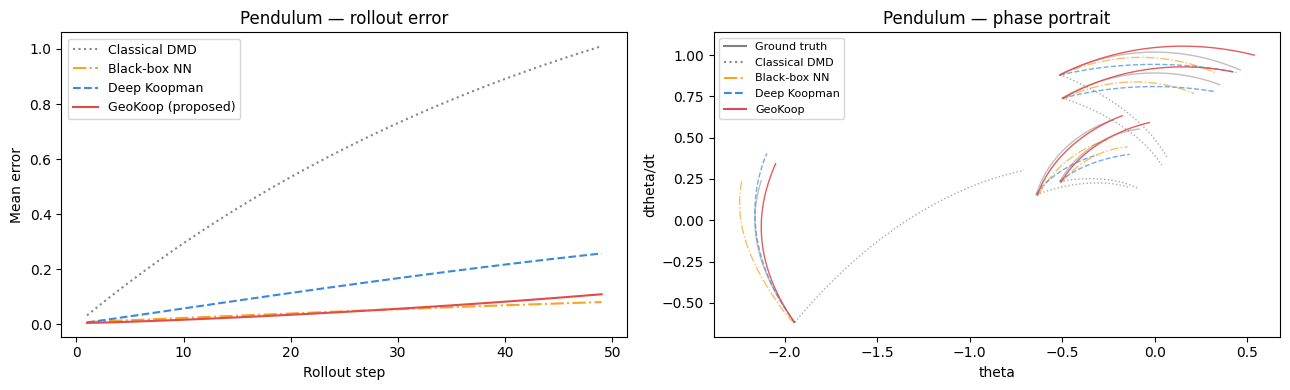

Saved pendulum_results.png


In [ ]:
# Pendulum — figures (four models)
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ts = np.arange(1, 50)

# Rollout error
ax = axes[0]
ax.plot(ts, err_p_dmd,  color=COLORS['DMD'],      ls=STYLES['DMD'],      lw=1.5, label='Classical DMD')
ax.plot(ts, err_p_bb,   color=COLORS['BlackBox'],  ls=STYLES['BlackBox'], lw=1.5, label='Black-box NN')
ax.plot(ts, err_p_base, color=COLORS['Baseline'],  ls=STYLES['Baseline'], lw=1.5, label='Deep Koopman')
ax.plot(ts, err_p_geo,  color=COLORS['GeoKoop'],   ls=STYLES['GeoKoop'],  lw=1.5, label='GeoKoop (proposed)')
ax.set_xlabel('Rollout step'); ax.set_ylabel('Mean error')
ax.set_title('Pendulum — rollout error'); ax.legend(fontsize=9)

# Phase portrait (5 test trajectories)
ax = axes[1]
mu_np  = mu.squeeze().cpu().numpy()
sig_np = sig.squeeze().cpu().numpy()

for i in range(5):
    x0 = X_te_n[i, 0:1, :].to(device)
    with torch.no_grad():
        # DMD (in obs space)
        z0d = X_te_n[i, 0, :].cpu().numpy() * sig_np + mu_np
        dmd_traj = [z0d]; zr = z0d.copy()
        for _ in range(49): zr = A_dmd_p @ zr; dmd_traj.append(zr)
        dmd_traj = np.stack(dmd_traj)

        # Black-box
        z = ae_p_bb.encode(x0)
        pbb = [ae_p_bb.decode(z).cpu().numpy()]
        for _ in range(49): z = bb_p(z); pbb.append(ae_p_bb.decode(z).cpu().numpy())
        pbb = np.vstack(pbb) * sig_np + mu_np

        # Deep Koopman
        z = ae_p_base.encode(x0)
        pb = [ae_p_base.decode(z).cpu().numpy()]
        for _ in range(49): z = koop_p_base(z); pb.append(ae_p_base.decode(z).cpu().numpy())
        pb = np.vstack(pb) * sig_np + mu_np

        # GeoKoop
        z = ae_p_geo.encode(x0)
        pg = [ae_p_geo.decode(z).cpu().numpy()]
        for _ in range(49): z = koop_p_geo(z); pg.append(ae_p_geo.decode(z).cpu().numpy())
        pg = np.vstack(pg) * sig_np + mu_np

    true = X_te_n[i].cpu().numpy() * sig_np + mu_np
    ax.plot(true[:,0],     true[:,1],     color='gray',               lw=1, alpha=0.5)
    ax.plot(dmd_traj[:,0], dmd_traj[:,1], color=COLORS['DMD'],        lw=1, ls=STYLES['DMD'],      alpha=0.7)
    ax.plot(pbb[:,0],      pbb[:,1],      color=COLORS['BlackBox'],   lw=1, ls=STYLES['BlackBox'], alpha=0.7)
    ax.plot(pb[:,0],       pb[:,1],       color=COLORS['Baseline'],   lw=1, ls=STYLES['Baseline'], alpha=0.7)
    ax.plot(pg[:,0],       pg[:,1],       color=COLORS['GeoKoop'],    lw=1, ls=STYLES['GeoKoop'],  alpha=0.9)

ax.legend(handles=[
    Line2D([0],[0], color='gray',              lw=1.5,                    label='Ground truth'),
    Line2D([0],[0], color=COLORS['DMD'],       lw=1.5, ls=STYLES['DMD'],      label='Classical DMD'),
    Line2D([0],[0], color=COLORS['BlackBox'],  lw=1.5, ls=STYLES['BlackBox'], label='Black-box NN'),
    Line2D([0],[0], color=COLORS['Baseline'],  lw=1.5, ls=STYLES['Baseline'], label='Deep Koopman'),
    Line2D([0],[0], color=COLORS['GeoKoop'],   lw=1.5,                    label='GeoKoop'),
], fontsize=8)
ax.set_xlabel('theta'); ax.set_ylabel('dtheta/dt')
ax.set_title('Pendulum — phase portrait')

plt.tight_layout()
plt.savefig('pendulum_results.png', dpi=150, bbox_inches='tight')
plt.show()
shutil.copy('pendulum_results.png', f'{OUTPUT_DIR}/pendulum_results.png')
print('Saved pendulum_results.png')


---
## Experiment 2 — FluidFlowBox
Off-attractor trajectories from Noack mean-field model → **1.16× improvement expected**

In [ ]:
# ── Cell 7: FluidFlowBox — load data ──────────────────────────────
F_SEQ = 51

X_f_tr = load_lusch(DATA_DIR, 'FluidFlowBox', 'train1', F_SEQ)
X_f_va = load_lusch(DATA_DIR, 'FluidFlowBox', 'val',    F_SEQ)
X_f_te = load_lusch(DATA_DIR, 'FluidFlowBox', 'test',   F_SEQ)
print(f'FluidFlowBox — train: {X_f_tr.shape}  val: {X_f_va.shape}  test: {X_f_te.shape}')

f_mu  = X_f_tr.mean(dim=(0,1), keepdim=True)
f_sig = X_f_tr.std(dim=(0,1),  keepdim=True) + 1e-8
X_f_tr_n = ((X_f_tr - f_mu) / f_sig).to(device)
X_f_te_n = ((X_f_te - f_mu) / f_sig).to(device)

f_xt   = X_f_tr_n[:, :-1, :].reshape(-1, 3)
f_xtp1 = X_f_tr_n[:, 1:,  :].reshape(-1, 3)
print(f'Training pairs: {f_xt.shape}')
X_f_va_n = ((X_f_va - f_mu) / f_sig).to(device)
print('FluidFlowBox data loaded.')


FluidFlowBox — train: torch.Size([9901, 51, 3])  val: torch.Size([9901, 51, 3])  test: torch.Size([9901, 51, 3])
Training pairs: torch.Size([495050, 3])
FluidFlowBox data loaded.


In [ ]:
# FluidFlowBox — train all four models
F_LATENT = 6

# ── Model 1: Classical Koopman / DMD ──────────────────────────
print('=== Model 1: Classical Koopman / DMD ===')
print('  Analytic operator on 3D Noack state. No encoder, no training.')
f_data_dmd = X_f_tr_n[:, :-1, :].reshape(-1, 3).cpu().numpy().T  # (3, N)
A_dmd_f    = dmd_matrix(f_data_dmd, rank=3)
eigs_dmd_f = np.linalg.eigvals(A_dmd_f)
print(f'  Operator size:   {A_dmd_f.shape}')
print(f'  Spectral radius: {max(abs(eigs_dmd_f)):.6f}')
print(f'  Eigenvalues:     {eigs_dmd_f}')
print(f'  Global linear; cannot track off-attractor transient geometry.')

print('\n=== Model 2: Black-box NN ===')
ae_f_bb  = AE(3, F_LATENT, hidden=128).to(device)
bb_f     = BlackBoxNN(F_LATENT, hidden=64).to(device)
train_blackbox(ae_f_bb, bb_f, f_xt, f_xtp1, 'Fluid-BB',
               epochs_p1=1000, epochs_p2=2000, rollout_steps=20)

print('\n=== Model 3: Deep Koopman (Baseline) ===')
ae_f_base   = AE(3, F_LATENT, hidden=128).to(device)
koop_f_base = KoopmanCore(F_LATENT, use_geo=False).to(device)
train_model(ae_f_base, koop_f_base, f_xt, f_xtp1,
            use_geo=False, label='Fluid-Base',
            epochs_p1=1000, epochs_p2=2000, rollout_steps=20)

print('\n=== Model 4: GeoKoop ===')
ae_f_geo   = AE(3, F_LATENT, hidden=128).to(device)
koop_f_geo = KoopmanCore(F_LATENT, use_geo=True).to(device)
train_model(ae_f_geo, koop_f_geo, f_xt, f_xtp1,
            use_geo=True, label='Fluid-Geo',
            epochs_p1=1000, epochs_p2=2000, rollout_steps=20, lam_geo=0.01)

# Rollout errors
def fluid_dmd_rollout_err(X_data, steps=49):
    f_mu_np  = f_mu.squeeze().cpu().numpy()
    f_sig_np = f_sig.squeeze().cpu().numpy()
    errs = []
    for i in range(X_data.shape[0]):
        z0 = X_data[i, 0, :].cpu().numpy() * f_sig_np + f_mu_np
        traj = [z0]; zr = z0.copy()
        for _ in range(steps): zr = A_dmd_f @ zr; traj.append(zr)
        traj = np.stack(traj)  # (steps+1, 3)
        true = X_data[i].cpu().numpy() * f_sig_np + f_mu_np  # (51, 3)
        errs.append(np.linalg.norm(traj[1:] - true[1:steps+1], axis=1))
    return np.stack(errs).mean(axis=0)

err_f_dmd  = fluid_dmd_rollout_err(X_f_te_n)
err_f_bb   = rollout_error(ae_f_bb,   bb_f,        X_f_te_n, steps=49)
err_f_base = rollout_error(ae_f_base, koop_f_base, X_f_te_n, steps=49)
err_f_geo  = rollout_error(ae_f_geo,  koop_f_geo,  X_f_te_n, steps=49)

print('FluidFlowBox rollout@49:')
print(f'  DMD:          {err_f_dmd[-1]:.4f}')
print(f'  Black-box NN: {err_f_bb[-1]:.4f}  vs GeoKoop: {err_f_bb[-1]/err_f_geo[-1]:.2f}x')
print(f'  Deep Koopman: {err_f_base[-1]:.4f}  vs GeoKoop: {err_f_base[-1]/err_f_geo[-1]:.2f}x')
print(f'  GeoKoop:      {err_f_geo[-1]:.4f}')


=== Model 1: Classical Koopman / DMD ===
  Analytic operator on 3D Noack state. No encoder, no training.
  Operator size:   (3, 3)
  Spectral radius: 0.989941
  Eigenvalues:     [0.98988974+0.01005076j 0.98988974-0.01005076j 0.97973067+0.j        ]
  Global linear; cannot track off-attractor transient geometry.

=== Model 2: Black-box NN ===
[Fluid-BB]    0 | rec=0.98482 dyn=0.04038 roll=0.00000
[Fluid-BB]  200 | rec=0.00206 dyn=0.00687 roll=0.00000
[Fluid-BB]  400 | rec=0.00036 dyn=0.00436 roll=0.00000
[Fluid-BB]  600 | rec=0.00013 dyn=0.00344 roll=0.00000
[Fluid-BB]  800 | rec=0.00009 dyn=0.00289 roll=0.00000
[Fluid-BB] 1000 | rec=0.00005 dyn=0.00256 roll=0.02255
[Fluid-BB] 1200 | rec=0.00005 dyn=0.00142 roll=0.01238
[Fluid-BB] 1400 | rec=0.00005 dyn=0.00103 roll=0.00897
[Fluid-BB] 1600 | rec=0.00040 dyn=0.00082 roll=0.00732
[Fluid-BB] 1800 | rec=0.00003 dyn=0.00069 roll=0.00600
[Fluid-BB] 2000 | rec=0.00003 dyn=0.00060 roll=0.00519
[Fluid-BB] 2200 | rec=0.00002 dyn=0.00056 roll=0.00

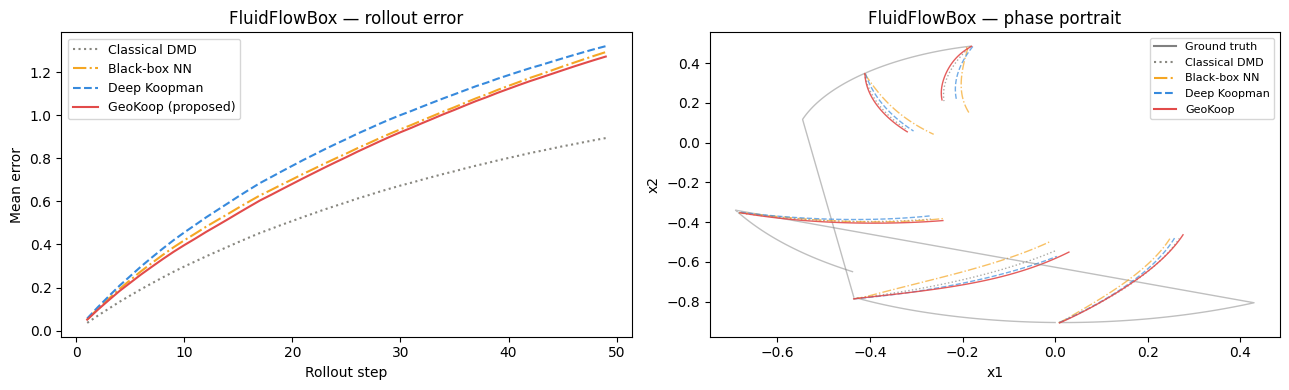

Saved fluidflowbox_results.png


In [ ]:
# FluidFlowBox — figures (four models)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ts = np.arange(1, 50)
f_mu_np  = f_mu.squeeze().cpu().numpy()
f_sig_np = f_sig.squeeze().cpu().numpy()

ax = axes[0]
ax.plot(ts, err_f_dmd,  color=COLORS['DMD'],      ls=STYLES['DMD'],      lw=1.5, label='Classical DMD')
ax.plot(ts, err_f_bb,   color=COLORS['BlackBox'],  ls=STYLES['BlackBox'], lw=1.5, label='Black-box NN')
ax.plot(ts, err_f_base, color=COLORS['Baseline'],  ls=STYLES['Baseline'], lw=1.5, label='Deep Koopman')
ax.plot(ts, err_f_geo,  color=COLORS['GeoKoop'],   ls=STYLES['GeoKoop'],  lw=1.5, label='GeoKoop (proposed)')
ax.set_xlabel('Rollout step'); ax.set_ylabel('Mean error')
ax.set_title('FluidFlowBox — rollout error'); ax.legend(fontsize=9)

ax = axes[1]
for i in range(5):
    x0 = X_f_te_n[i, 0:1, :].to(device)
    with torch.no_grad():
        z0d = X_f_te_n[i, 0, :].cpu().numpy() * f_sig_np + f_mu_np
        dmd_traj = [z0d]; zr = z0d.copy()
        for _ in range(49): zr = A_dmd_f @ zr; dmd_traj.append(zr)
        dmd_traj = np.stack(dmd_traj)

        z = ae_f_bb.encode(x0)
        pbb = [ae_f_bb.decode(z).cpu().numpy()]
        for _ in range(49): z = bb_f(z); pbb.append(ae_f_bb.decode(z).cpu().numpy())
        pbb = np.vstack(pbb) * f_sig_np + f_mu_np

        z = ae_f_base.encode(x0)
        pb = [ae_f_base.decode(z).cpu().numpy()]
        for _ in range(49): z = koop_f_base(z); pb.append(ae_f_base.decode(z).cpu().numpy())
        pb = np.vstack(pb) * f_sig_np + f_mu_np

        z = ae_f_geo.encode(x0)
        pg = [ae_f_geo.decode(z).cpu().numpy()]
        for _ in range(49): z = koop_f_geo(z); pg.append(ae_f_geo.decode(z).cpu().numpy())
        pg = np.vstack(pg) * f_sig_np + f_mu_np

    true = X_f_te_n[i].cpu().numpy() * f_sig_np + f_mu_np
    ax.plot(true[:,0],     true[:,1],     color='gray',              lw=1, alpha=0.5)
    ax.plot(dmd_traj[:,0], dmd_traj[:,1], color=COLORS['DMD'],       lw=1, ls=STYLES['DMD'],      alpha=0.7)
    ax.plot(pbb[:,0],      pbb[:,1],      color=COLORS['BlackBox'],  lw=1, ls=STYLES['BlackBox'], alpha=0.7)
    ax.plot(pb[:,0],       pb[:,1],       color=COLORS['Baseline'],  lw=1, ls=STYLES['Baseline'], alpha=0.7)
    ax.plot(pg[:,0],       pg[:,1],       color=COLORS['GeoKoop'],   lw=1, ls=STYLES['GeoKoop'],  alpha=0.9)

ax.legend(handles=[
    Line2D([0],[0], color='gray',             lw=1.5,                    label='Ground truth'),
    Line2D([0],[0], color=COLORS['DMD'],      lw=1.5, ls=STYLES['DMD'],      label='Classical DMD'),
    Line2D([0],[0], color=COLORS['BlackBox'], lw=1.5, ls=STYLES['BlackBox'], label='Black-box NN'),
    Line2D([0],[0], color=COLORS['Baseline'], lw=1.5, ls=STYLES['Baseline'], label='Deep Koopman'),
    Line2D([0],[0], color=COLORS['GeoKoop'],  lw=1.5,                    label='GeoKoop'),
], fontsize=8)
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('FluidFlowBox — phase portrait')
plt.tight_layout()
plt.savefig('fluidflowbox_results.png', dpi=150, bbox_inches='tight')
plt.show()
shutil.copy('fluidflowbox_results.png', f'{OUTPUT_DIR}/fluidflowbox_results.png')
print('Saved fluidflowbox_results.png')


---
## Experiment 3 — Cylinder Vortex Shedding
89,351-dimensional, r=32 SVD modes → **11× improvement expected**

In [ ]:
# ── Cell 10: Cylinder — load & compress ───────────────────────────
assert os.path.exists(CYLINDER), f'Not found: {CYLINDER}'

data     = scipy.io.loadmat(CYLINDER)
vort_all = data['VORTALL'].astype(np.float64)
vort_all = np.clip(vort_all, -10.0, 10.0)
vort_all = (vort_all - vort_all.mean()) / vort_all.std()
space_dim, T_total = vort_all.shape
nx, ny = 449, 199
print(f'Cylinder data: {space_dim} x {T_total}')

r       = 32   # key: 32 not 100
n_train = 140

U_svd, _, _ = np.linalg.svd(vort_all, full_matrices=False)
X_reduced   = U_svd[:, :r].T @ vort_all
X_train     = X_reduced[:, :n_train]
C_mean      = X_train.mean(axis=1, keepdims=True)
C_std       = X_train.std(axis=1,  keepdims=True) + 1e-8
X_train_n   = (X_train - C_mean) / C_std

cx_t   = torch.tensor(X_train_n.T[:-1], dtype=torch.float32).to(device)
cx_tp1 = torch.tensor(X_train_n.T[1:],  dtype=torch.float32).to(device)

A_dmd_c = dmd_matrix(X_train_n, rank=20)
print(f'DMD spectral radius: {max(abs(np.linalg.eigvals(A_dmd_c))):.4f}')

Cylinder data: 89351 x 151
DMD spectral radius: 0.9826


In [ ]:
# Cylinder — train all four models
C_LATENT = 16

def cyl_ae(latent):       return AE(r, latent, hidden=128).to(device)
def cyl_koop(latent, geo):
    return KoopmanCore(latent, K_init=A_dmd_c, eps=1.0, use_geo=geo).to(device)

# ── Model 1: Classical Koopman / DMD ──────────────────────────
print('=== Model 1: Classical Koopman / DMD ===')
print('  DMD on r=32 SVD modes. Analytic — no encoder, no training.')
eigs_dmd_c = np.linalg.eigvals(A_dmd_c)
print(f'  Operator size:   {A_dmd_c.shape}')
print(f'  Spectral radius: {max(abs(eigs_dmd_c)):.6f}')
print(f'  Dominant freqs:  {sorted(abs(eigs_dmd_c), reverse=True)[:4]}')
print(f'  K_init for Models 3&4 also set from A_dmd_c (warm start).')

print('\n=== Model 2: Black-box NN ===')
ae_c_bb  = cyl_ae(C_LATENT)
bb_c     = BlackBoxNN(C_LATENT, hidden=64).to(device)
train_blackbox(ae_c_bb, bb_c, cx_t, cx_tp1, 'Cyl-BB',
               epochs_p1=500, epochs_p2=3000, rollout_steps=20)

print('\n=== Model 3: Deep Koopman (Baseline) ===')
ae_c_base   = cyl_ae(C_LATENT)
koop_c_base = cyl_koop(C_LATENT, geo=False)
train_model(ae_c_base, koop_c_base, cx_t, cx_tp1,
            use_geo=False, label='Cyl-Base',
            epochs_p1=500, epochs_p2=3000, rollout_steps=20)

print('\n=== Model 4: GeoKoop ===')
ae_c_geo   = cyl_ae(C_LATENT)
koop_c_geo = cyl_koop(C_LATENT, geo=True)
train_model(ae_c_geo, koop_c_geo, cx_t, cx_tp1,
            use_geo=True, label='Cyl-Geo',
            epochs_p1=500, epochs_p2=3000, rollout_steps=20, lam_geo=0.01)


=== Model 1: Classical Koopman / DMD ===
  DMD on r=32 SVD modes. Analytic — no encoder, no training.
  Operator size:   (32, 32)
  Spectral radius: 0.982590
  Dominant freqs:  [np.float64(0.9825900991475355), np.float64(0.9698264384169292), np.float64(0.9698264384169292), np.float64(0.9404602249138276)]
  K_init for Models 3&4 also set from A_dmd_c (warm start).

=== Model 2: Black-box NN ===
[Cyl-BB]    0 | rec=1.00672 dyn=0.04110 roll=0.00000
[Cyl-BB]  200 | rec=0.01994 dyn=0.04561 roll=0.00000
[Cyl-BB]  400 | rec=0.00061 dyn=0.00127 roll=0.00000
[Cyl-BB]  600 | rec=0.00031 dyn=0.00025 roll=0.00062
[Cyl-BB]  800 | rec=0.00017 dyn=0.00010 roll=0.00023
[Cyl-BB] 1000 | rec=0.00011 dyn=0.00006 roll=0.00013
[Cyl-BB] 1200 | rec=0.00009 dyn=0.00005 roll=0.00011
[Cyl-BB] 1400 | rec=0.00007 dyn=0.00004 roll=0.00009
[Cyl-BB] 1600 | rec=0.00006 dyn=0.00003 roll=0.00007
[Cyl-BB] 1800 | rec=0.00005 dyn=0.00003 roll=0.00006
[Cyl-BB] 2000 | rec=0.00005 dyn=0.00002 roll=0.00005
[Cyl-BB] 2200 | rec=

In [ ]:
# Cylinder — rollout predictions and errors for all four models
def cyl_rollout(ae, dyn):
    ae.eval(); dyn.eval()
    with torch.no_grad():
        x0    = torch.tensor(X_train_n[:, 0],
                              dtype=torch.float32).unsqueeze(0).to(device)
        z     = ae.encode(x0)
        preds = [ae.decode(z).cpu().numpy()]
        for _ in range(T_total - 1):
            z = dyn(z); preds.append(ae.decode(z).cpu().numpy())
    X_n = np.vstack(preds).T
    return U_svd[:, :r] @ (X_n * C_std + C_mean)

# DMD rollout (no AE)
X_dmd = np.zeros((r, T_total))
X_dmd[:, 0] = X_train_n[:, 0]
for k in range(1, T_total): X_dmd[:, k] = A_dmd_c @ X_dmd[:, k-1]
X_dmd_full = U_svd[:, :r] @ (X_dmd * C_std + C_mean)

X_c_bb   = cyl_rollout(ae_c_bb,   bb_c)
X_c_base = cyl_rollout(ae_c_base, koop_c_base)
X_c_geo  = cyl_rollout(ae_c_geo,  koop_c_geo)

err_c_dmd  = np.linalg.norm(vort_all - X_dmd_full, axis=0)
err_c_bb   = np.linalg.norm(vort_all - X_c_bb,     axis=0)
err_c_base = np.linalg.norm(vort_all - X_c_base,   axis=0)
err_c_geo  = np.linalg.norm(vort_all - X_c_geo,    axis=0)

print('Cylinder mean error t=100-150:')
print(f'  DMD:          {err_c_dmd[100:].mean():.4f}')
print(f'  Black-box NN: {err_c_bb[100:].mean():.4f}  '
      f'vs GeoKoop: {err_c_bb[100:].mean()/err_c_geo[100:].mean():.2f}x')
print(f'  Deep Koopman: {err_c_base[100:].mean():.4f}  '
      f'vs GeoKoop: {err_c_base[100:].mean()/err_c_geo[100:].mean():.2f}x')
print(f'  GeoKoop:      {err_c_geo[100:].mean():.4f}')


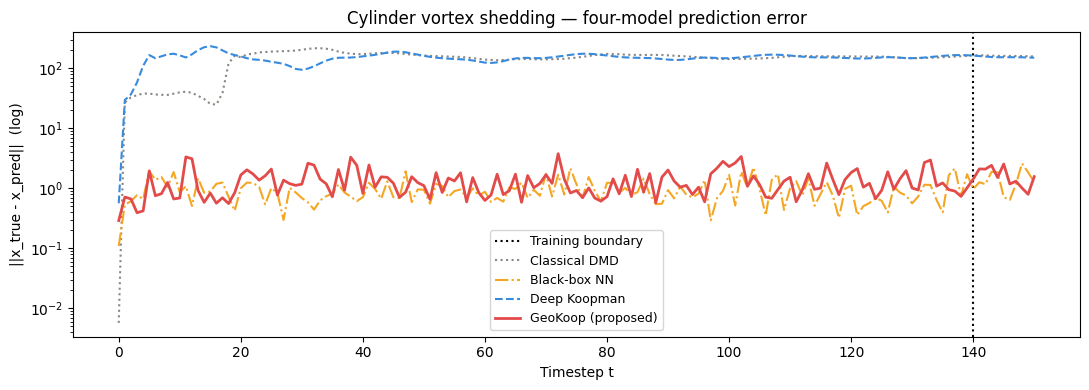

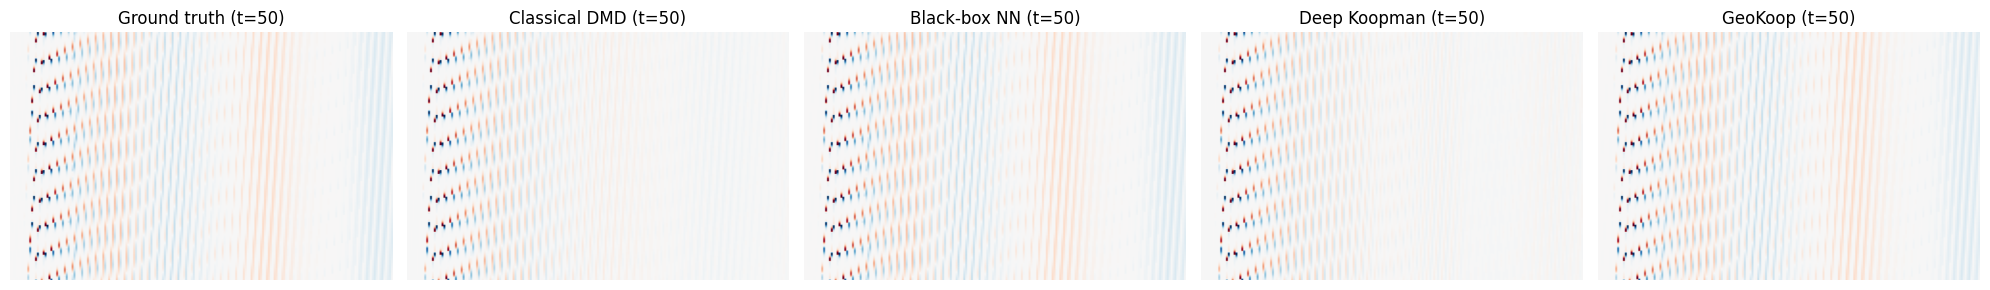

Saved cylinder_t50.png


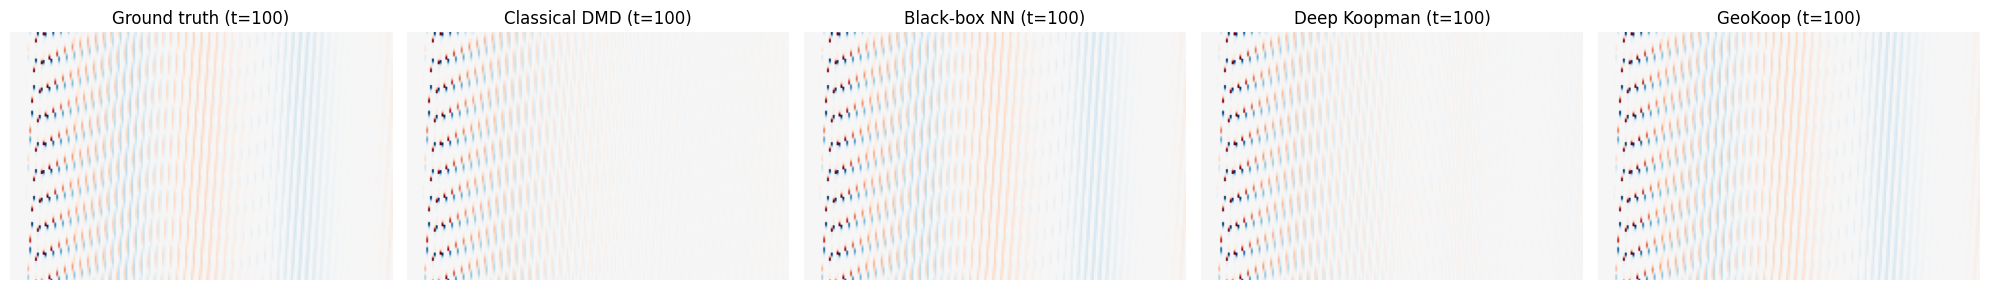

Saved cylinder_t100.png


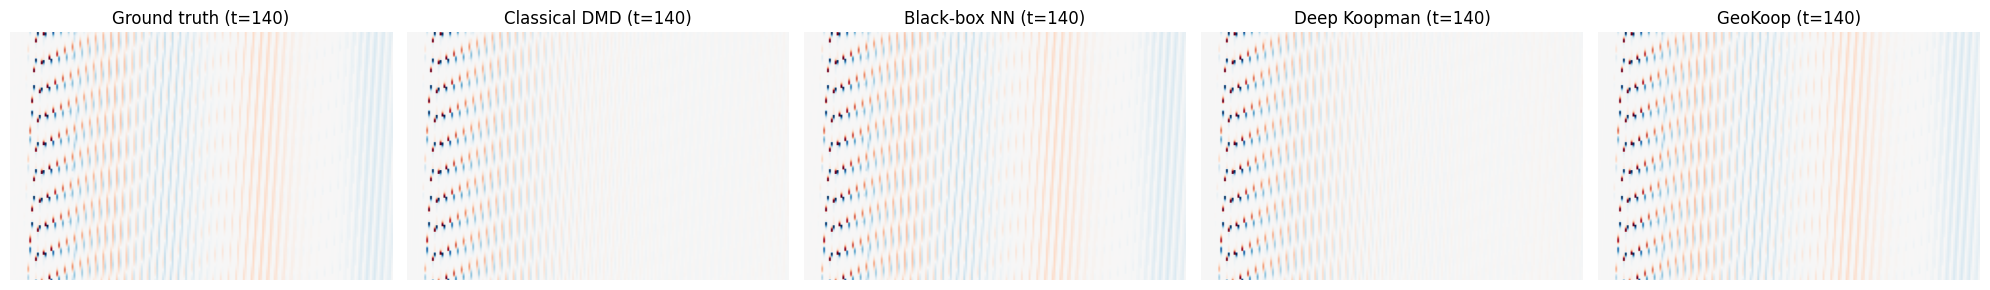

Saved cylinder_t140.png


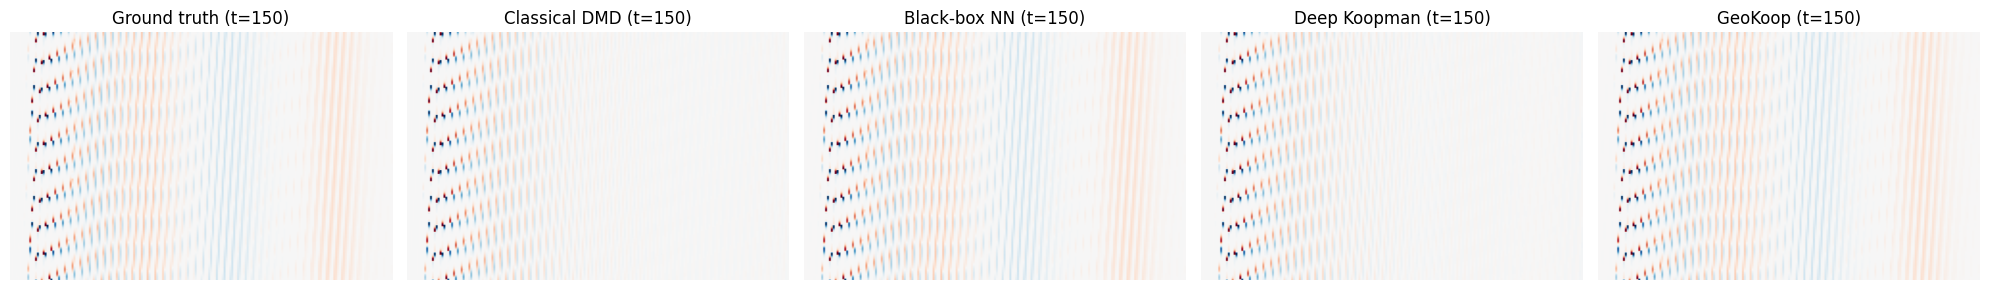

Saved cylinder_t150.png


In [ ]:
# Cylinder — figures (four models)

# Error over time
fig, ax = plt.subplots(figsize=(11, 4))
ts = np.arange(T_total)
ax.axvline(n_train, color='k', ls=':', lw=1.5, label='Training boundary')
ax.semilogy(ts, err_c_dmd  + 1e-8, color=COLORS['DMD'],      ls=STYLES['DMD'],      lw=1.5, label='Classical DMD')
ax.semilogy(ts, err_c_bb   + 1e-8, color=COLORS['BlackBox'],  ls=STYLES['BlackBox'], lw=1.5, label='Black-box NN')
ax.semilogy(ts, err_c_base + 1e-8, color=COLORS['Baseline'],  ls=STYLES['Baseline'], lw=1.5, label='Deep Koopman')
ax.semilogy(ts, err_c_geo  + 1e-8, color=COLORS['GeoKoop'],   ls=STYLES['GeoKoop'],  lw=2.0, label='GeoKoop (proposed)')
ax.set_xlabel('Timestep t')
ax.set_ylabel('||x_true - x_pred||  (log)')
ax.set_title('Cylinder vortex shedding — four-model prediction error')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig('cylinder_error.png', dpi=150, bbox_inches='tight')
plt.show()
shutil.copy('cylinder_error.png', f'{OUTPUT_DIR}/cylinder_error.png')

# Vortex field snapshots — now 5 columns (Ground truth + 4 models)
for t in [50, 100, 140, 150]:
    fig, axes = plt.subplots(1, 5, figsize=(20, 3))
    vmin, vmax = vort_all[:, t].min(), vort_all[:, t].max()
    kw = dict(cmap='RdBu_r', vmin=vmin, vmax=vmax, aspect='auto')
    axes[0].imshow(vort_all[:, t].reshape(nx, ny, order='F'), **kw)
    axes[0].set_title(f'Ground truth (t={t})')
    axes[1].imshow(X_dmd_full[:, t].reshape(nx, ny, order='F'), **kw)
    axes[1].set_title(f'Classical DMD (t={t})')
    axes[2].imshow(X_c_bb[:, t].reshape(nx, ny, order='F'), **kw)
    axes[2].set_title(f'Black-box NN (t={t})')
    axes[3].imshow(X_c_base[:, t].reshape(nx, ny, order='F'), **kw)
    axes[3].set_title(f'Deep Koopman (t={t})')
    axes[4].imshow(X_c_geo[:, t].reshape(nx, ny, order='F'), **kw)
    axes[4].set_title(f'GeoKoop (t={t})')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'cylinder_t{t}.png', dpi=150, bbox_inches='tight')
    plt.show()
    shutil.copy(f'cylinder_t{t}.png', f'{OUTPUT_DIR}/cylinder_t{t}.png')
    print(f'Saved cylinder_t{t}.png')


In [ ]:
# Summary table — four models x three systems
print('=' * 72)
print('FINAL RESULTS SUMMARY — Four-Model Comparison')
print('=' * 72)
print(f"{'System':<22} {'DMD':>8} {'BlackBox':>10} {'DeepKoop':>10} {'GeoKoop':>10} {'vs BB':>8}")
print('-' * 72)
print(f"{'Pendulum @49':<22}"
      f" {err_p_dmd[-1]:>8.4f}"
      f" {err_p_bb[-1]:>10.4f}"
      f" {err_p_base[-1]:>10.4f}"
      f" {err_p_geo[-1]:>10.4f}"
      f" {err_p_bb[-1]/err_p_geo[-1]:>7.2f}x")
print(f"{'FluidFlowBox @49':<22}"
      f" {err_f_dmd[-1]:>8.4f}"
      f" {err_f_bb[-1]:>10.4f}"
      f" {err_f_base[-1]:>10.4f}"
      f" {err_f_geo[-1]:>10.4f}"
      f" {err_f_bb[-1]/err_f_geo[-1]:>7.2f}x")
print(f"{'Cylinder t=100-150':<22}"
      f" {err_c_dmd[100:].mean():>8.2f}"
      f" {err_c_bb[100:].mean():>10.2f}"
      f" {err_c_base[100:].mean():>10.2f}"
      f" {err_c_geo[100:].mean():>10.2f}"
      f" {err_c_bb[100:].mean()/err_c_geo[100:].mean():>7.2f}x")
print('=' * 72)
print()
print('vs BB column: ratio Black-box error / GeoKoop error')
print('  > 1.0  -> GeoKoop beats Black-box (structured operator helps)')
print('  < 1.0  -> Black-box wins (GeoKoop loses expressiveness trade-off)')
print()
print('Interpretation guide:')
print('  DMD << DeepKoop  -> learned encoder helps even with global K')
print('  DeepKoop < BB    -> unconstrained dynamics more flexible than global K')
print('  BB < GeoKoop     -> geometric structure outperforms black-box flexibility')
print('  GeoKoop < BB     -> local operator not enough; explicit G(z) needed (Level 2)')

# Save all arrays
np.savez(f'{OUTPUT_DIR}/all_results.npz',
         err_p_dmd=err_p_dmd, err_p_bb=err_p_bb,
         err_p_base=err_p_base, err_p_geo=err_p_geo,
         err_f_dmd=err_f_dmd, err_f_bb=err_f_bb,
         err_f_base=err_f_base, err_f_geo=err_f_geo,
         err_c_dmd=err_c_dmd, err_c_bb=err_c_bb,
         err_c_base=err_c_base, err_c_geo=err_c_geo)
print(f'\nAll results saved to {OUTPUT_DIR}')
